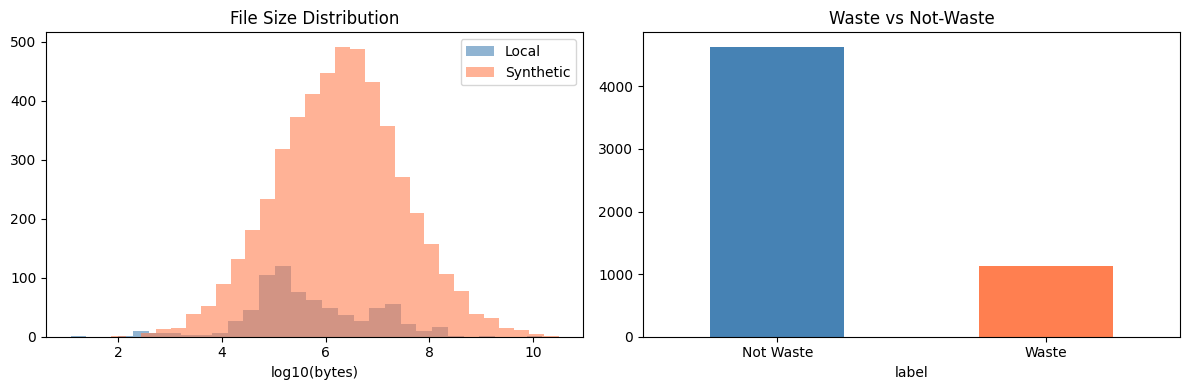

Grafik kaydedildi.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boyut dağılımı
df_local = df[df['source'] == 'local']
df_synth = df[df['source'] == 'synthetic']
axes[0].hist(np.log10(df_local['size_bytes']+1), bins=30, alpha=0.6, label='Local', color='steelblue')
axes[0].hist(np.log10(df_synth['size_bytes']+1), bins=30, alpha=0.6, label='Synthetic', color='coral')
axes[0].set_title('File Size Distribution')
axes[0].set_xlabel('log10(bytes)')
axes[0].legend()

# Waste oranı
df['label'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue','coral'])
axes[1].set_title('Waste vs Not-Waste')
axes[1].set_xticklabels(['Not Waste', 'Waste'], rotation=0)

plt.tight_layout()
plt.savefig('../outputs/figures/exploration.png', dpi=150)
plt.show()
print("Grafik kaydedildi.")

In [2]:
import sys
sys.path.insert(0, '..')
import yaml
from src.features import build_features
from src.labeling import create_labels

cfg = yaml.safe_load(open('../config/settings.yaml'))
df = build_features(df, cfg)
df = create_labels(df)

print(f"Waste dosyalar: {df['label'].sum()} / {len(df)}")
print(f"\nExt kategorileri:")
print(df['ext_category'].value_counts())

Waste dosyalar: 1134 / 5766

Ext kategorileri:
ext_category
document    2518
media       1913
code         766
archive      420
other        149
Name: count, dtype: int64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

df = pd.read_csv('../data/processed/merged.csv')
print(f"Toplam satır: {len(df)}")
print(f"\nKaynaklar:")
print(df['source'].value_counts())
print(f"\nSütunlar: {list(df.columns)}")

Toplam satır: 5766

Kaynaklar:
source
synthetic    5000
local         736
open_data      30
Name: count, dtype: int64

Sütunlar: ['file_id', 'extension', 'size_bytes', 'last_access', 'created', 'days_since_access', 'age_days', 'source']
